<a href="https://colab.research.google.com/github/Adeline187/Build_and_Deploy-ML/blob/main/EXPT5/K_means_clustering%2BPCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**Generate datasets for K means**

In [2]:
# Generate a 2D dataset with 3 clusters
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

df_kmeans = pd.DataFrame(
    X,
    columns=['Feature_1', 'Feature_2']
)

print("Original K-Means Dataset:")
print(df_kmeans.head())

Original K-Means Dataset:
   Feature_1  Feature_2
0  -7.155244  -7.390016
1  -7.395875  -7.110843
2  -2.015671   8.281780
3   4.509270   2.632436
4  -8.102502  -7.484961


**Elbow Method**

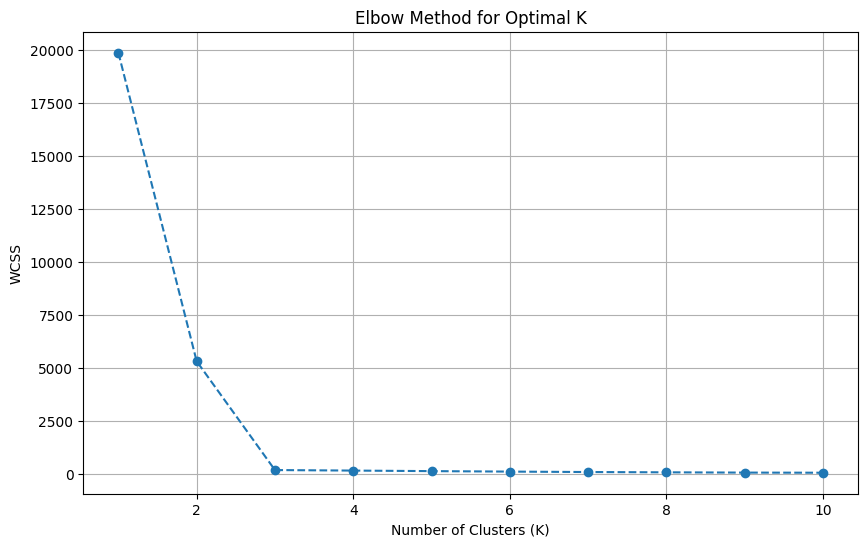

In [3]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

**Apply K-means**

In [4]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df_kmeans['Cluster'] = clusters

print(df_kmeans.head())

   Feature_1  Feature_2  Cluster
0  -7.155244  -7.390016        1
1  -7.395875  -7.110843        1
2  -2.015671   8.281780        0
3   4.509270   2.632436        2
4  -8.102502  -7.484961        1


**Visualize K-means cluster**

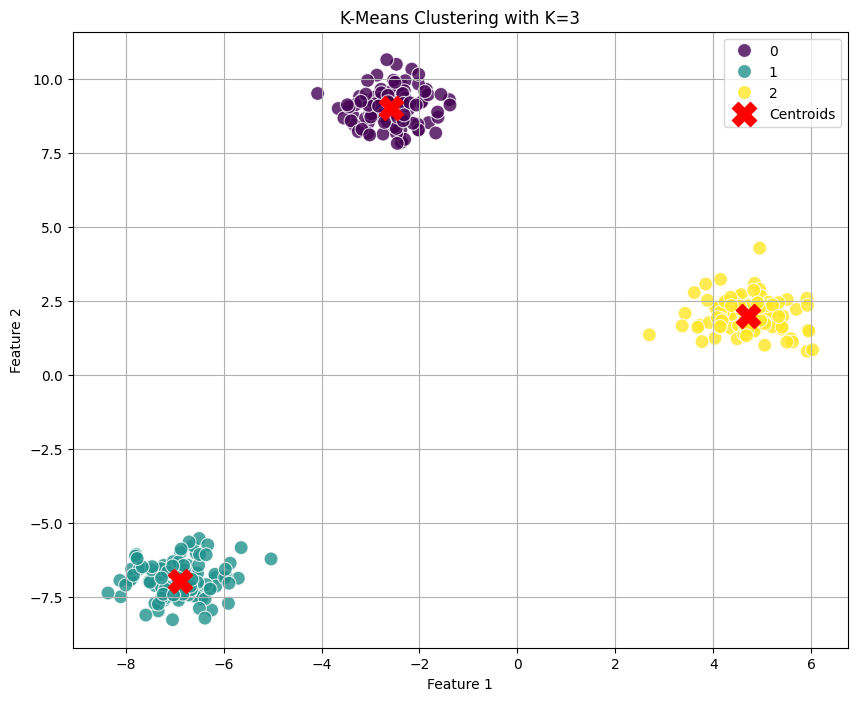

In [5]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='Feature_1',
    y='Feature_2',
    hue='Cluster',
    data=df_kmeans,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering with K=3')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

**Silhoutte score**

In [6]:
silhouette_avg = silhouette_score(X, clusters)

print("Silhouette Score for K-Means:", round(silhouette_avg, 3))

Silhouette Score for K-Means: 0.908


**Generate 4D dataset**

In [7]:
X_pca, y_pca = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.0,
    random_state=25
)

df_pca_original = pd.DataFrame(
    X_pca,
    columns=[f'Feature_{i+1}' for i in range(X_pca.shape[1])]
)

df_pca_original['True_Cluster'] = y_pca

print("Original PCA Dataset:")
print(df_pca_original.head())

print("\nDataset Shape:", df_pca_original.shape)

Original PCA Dataset:
   Feature_1  Feature_2  Feature_3  Feature_4  True_Cluster
0  -0.638667   1.110057  -6.400722  -0.204990             3
1  -2.951556  -7.657445   3.844794   0.903589             1
2  -0.253177   2.125103  -7.869801   0.559678             3
3  -2.151209   3.401400  -5.734930   0.965230             3
4  -2.347519  -7.230467   3.478891  -0.443440             1

Dataset Shape: (500, 5)


**Standardise the dataset**

In [8]:
scaler = StandardScaler()

X_pca_scaled = scaler.fit_transform(X_pca)

print("Scaled Data Shape:", X_pca_scaled.shape)

Scaled Data Shape: (500, 4)


**Apply PCA**

In [9]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_pca_scaled)

df_principal_components = pd.DataFrame(
    principal_components,
    columns=['Principal_Component_1', 'Principal_Component_2']
)

df_principal_components['True_Cluster'] = y_pca

explained_variance = pca.explained_variance_ratio_

print("Principal Components:")
print(df_principal_components.head())

print("\nExplained Variance Ratio:")
print(explained_variance)

print(
    "\nTotal Explained Variance by 2 PCs:",
    round(explained_variance.sum(), 3)
)

Principal Components:
   Principal_Component_1  Principal_Component_2  True_Cluster
0               0.455305               1.623917             3
1              -2.705622               0.375012             1
2               0.810234               1.966926             3
3               0.427139               2.149626             3
4              -2.407508               0.099250             1

Explained Variance Ratio:
[0.57208431 0.33622342]

Total Explained Variance by 2 PCs: 0.908


**Visualise PCA**

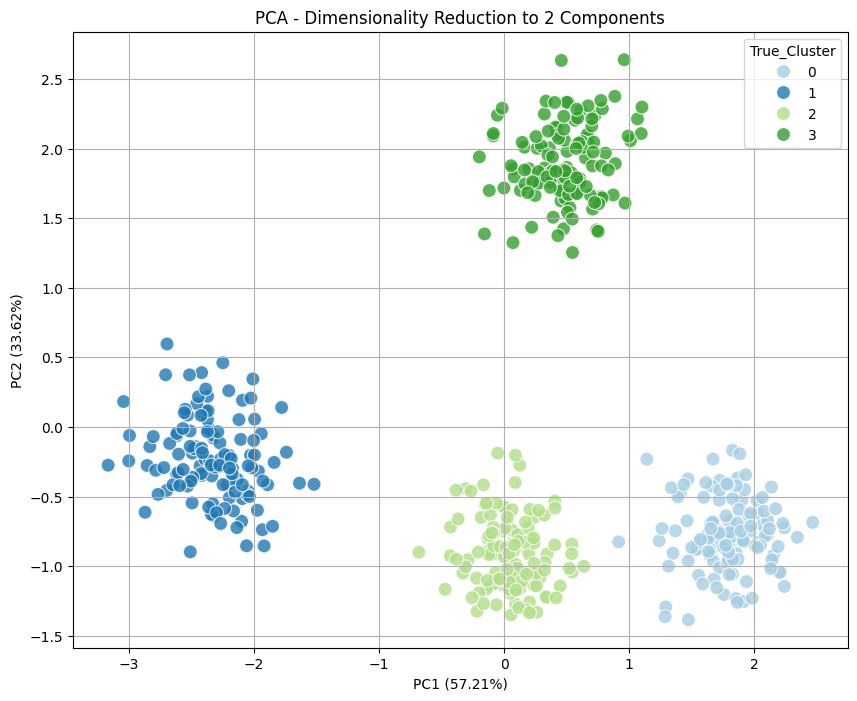

In [10]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='True_Cluster',
    data=df_principal_components,
    palette='Paired',
    s=100,
    alpha=0.8
)

plt.title('PCA - Dimensionality Reduction to 2 Components')

plt.xlabel(
    f'PC1 ({explained_variance[0] * 100:.2f}%)'
)

plt.ylabel(
    f'PC2 ({explained_variance[1] * 100:.2f}%)'
)

plt.grid(True)
plt.show()

**Apply K-means to PCA reduced data**

In [11]:
kmeans_pca = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(principal_components)

df_principal_components['KMeans_Cluster_on_PCA'] = clusters_pca

print(df_principal_components.head())

   Principal_Component_1  Principal_Component_2  True_Cluster  \
0               0.455305               1.623917             3   
1              -2.705622               0.375012             1   
2               0.810234               1.966926             3   
3               0.427139               2.149626             3   
4              -2.407508               0.099250             1   

   KMeans_Cluster_on_PCA  
0                      0  
1                      2  
2                      0  
3                      0  
4                      2  


**Visualise K-means on PCA data**

In [12]:
kmeans_pca = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(principal_components)

df_principal_components['KMeans_Cluster_on_PCA'] = clusters_pca

print(df_principal_components.head())

   Principal_Component_1  Principal_Component_2  True_Cluster  \
0               0.455305               1.623917             3   
1              -2.705622               0.375012             1   
2               0.810234               1.966926             3   
3               0.427139               2.149626             3   
4              -2.407508               0.099250             1   

   KMeans_Cluster_on_PCA  
0                      0  
1                      2  
2                      0  
3                      0  
4                      2  


**Silhoutte score for PCA+K-meanss**

In [13]:
silhouette_avg_pca = silhouette_score(
    principal_components,
    clusters_pca
)

print(
    "Silhouette Score for K-Means on PCA-Reduced Data:",
    round(silhouette_avg_pca, 3)
)

Silhouette Score for K-Means on PCA-Reduced Data: 0.776
